# H0 -> TODOS LOS ALIMENTOS ENGORDAN IGUAL
# H1 -> AL MENOS UN ALIMENTO ENGORDAN DIFERENTE



In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv('alimento.csv')
df

,alimento,peso
0,1,1.2
1,1,1.3
2,1,1.2
3,1,1.4
4,1,1.2
5,1,1.5
6,2,1.2
7,2,1.3
8,2,1.2
9,2,1.5


Text(9.444444444444445, 0.5, 'Peso')

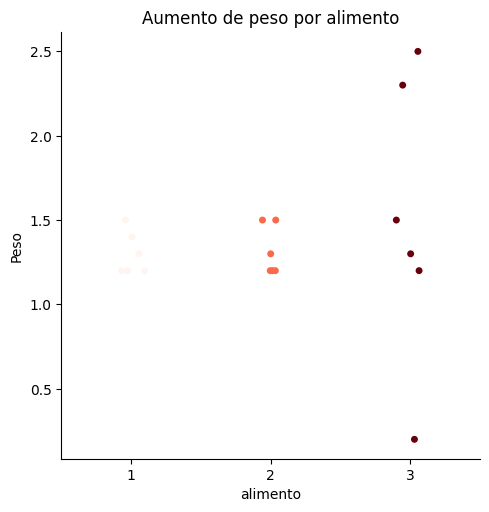

In [4]:
sns.catplot(x='alimento',y='peso',hue='alimento',data=df,palette='Reds',legend=False)
plt.title('Aumento de peso por alimento')
plt.xlabel('alimento')
plt.ylabel('Peso')

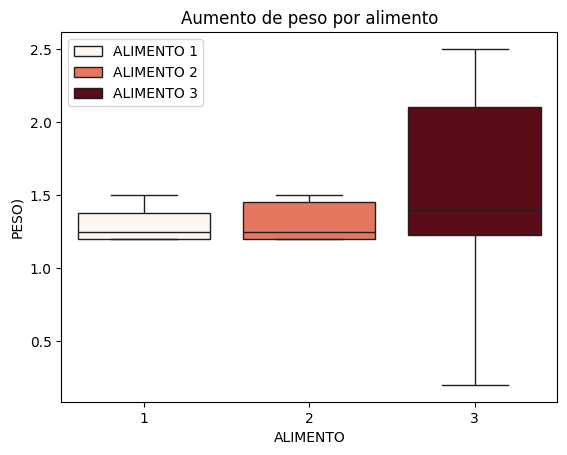

In [5]:
sns.boxplot(x='alimento',y='peso',hue='alimento',data=df,palette='Reds',orient = 'v')
plt.title('Aumento de peso por alimento')
plt.xlabel('ALIMENTO')
plt.ylabel('PESO)')
plt.legend(title='',labels=['ALIMENTO 1','ALIMENTO 2','ALIMENTO 3'])

In [6]:
import scipy.stats as stats
f_statistic, p_value = stats.f_oneway(df.peso[df.alimento==1],df.peso[df.alimento==2],df.peso[df.alimento==3])
print("Estadístico F:", f_statistic)
print("Valor p:", p_value)
alpha = 0.05
if p_value < alpha:
    print("Rechazamos la hipótesis nula")
else:
    print("No rechazamos la hipótesis nula")

Estadístico F: 0.3037916857012335
Valor p: 0.7424495814190768
No rechazamos la hipótesis nula


In [7]:
import statsmodels.api as sm
from statsmodels.formula.api import ols

model = ols('peso ~ C(alimento)', data=df).fit()
aov_table = sm.stats.anova_lm(model, typ=2)

aov_table

,sum_sq,df,F,PR(>F)
C(alimento),0.147778,2.0,0.303792,0.74245
Residual,3.648333,15.0,NaN,NaN


Text(0.5, 0.98, 'Verificación de Supuestos del Modelo ANOVA')

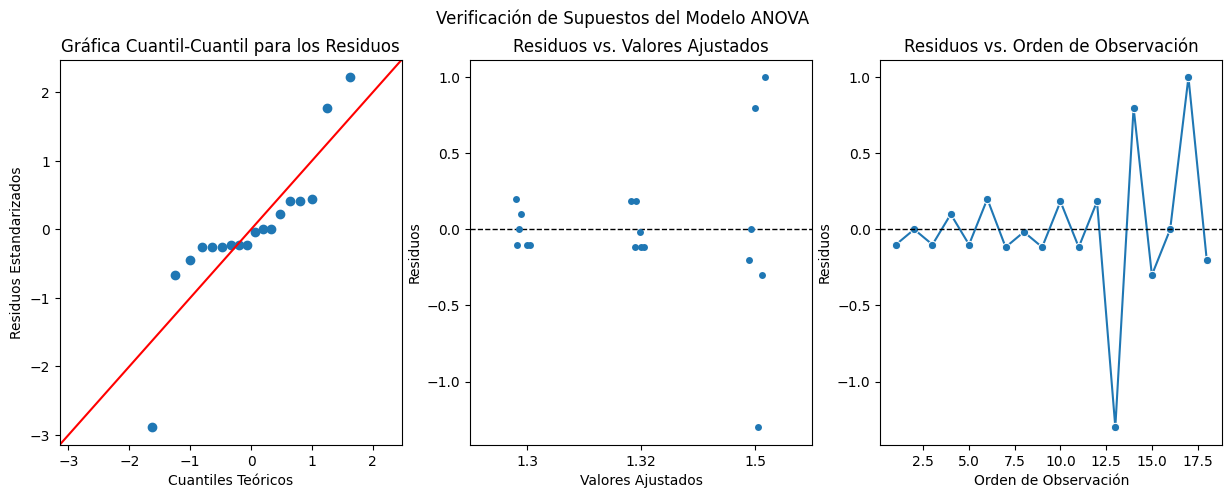

In [8]:
# Verificación de Supuestos

fig, axs = plt.subplots(ncols=3,figsize=(15,5))

res = model.resid
sm.qqplot(res,fit=True ,line='45',ax=axs[0])
axs[0].set_title('Gráfica Cuantil-Cuantil para los Residuos')
axs[0].set_xlabel("Cuantiles Teóricos")
axs[0].set_ylabel("Residuos Estandarizados")



adj = model.fittedvalues.round(2)
sns.stripplot(x=adj,y=res,ax=axs[1])
axs[1].axhline(y=0, color='black', linestyle='--', linewidth=1)
axs[1].set_ylabel('Residuos')
axs[1].set_xlabel('Valores Ajustados')
axs[1].set_title('Residuos vs. Valores Ajustados')


sns.lineplot(x=res.index+1,y=res,marker='o',ax=axs[2])
axs[2].axhline(y=0, color='black', linestyle='--', linewidth=1)
axs[2].set_title('Residuos vs. Orden de Observación')
axs[2].set_xlabel('Orden de Observación')
axs[2].set_ylabel('Residuos')

fig.suptitle('Verificación de Supuestos del Modelo ANOVA')


LA ANOVA PUEDE  NO SER VÁLIDA, YA QUE NO SE CUMPLE UN SUPUESTO

#ALTERNATIVA - KRUSKA WALLIS

In [12]:
from scipy import stats

result = stats.kruskal(df.peso[df.alimento==1],df.peso[df.alimento==2],df.peso[df.alimento==3])
print(result)

KruskalResult(statistic=np.float64(0.7028179458657814), pvalue=np.float64(0.703695902420834))
